# EDA -> Разведочный анализ данных

## Анализ сайта "СберАвтоподписка"

Цель ноутбука:

- выполнить первичный анализ исходных данных
- проверить качество данных
- изучить структуру таблиц `ga_sessions` и `ga_hits`
- сформировать целевую переменную
- провести первичный анализ конверсии

Примечание:

Запускать ноутбук необходимо из директории
`mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/notebooks/`

## Импорты

In [1]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import numpy as np
import pandas as pd

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

## Пути к данным

In [2]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.data_loader import load_raw_data
from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.config import TARGET_ACTIONS
from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.config import PROCESSED_DATA_DIR

## Загрузка данных

In [3]:
sessions, hits = load_raw_data()

print(f"Размер ga_sessions: {sessions.shape}")
print(f"Размер ga_hits: {hits.shape}")

Размер ga_sessions: (1860042, 18)
Размер ga_hits: (15726470, 11)


## Первичный просмотр ga_sessions

In [4]:
sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [5]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [6]:
sessions.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session_id,1860042,1860042,9055434745589932991.1637753792.1637753792,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_id,1860042,1391719,1750498477.1629450062,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_date,1860042,226,2021-05-24,39453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_time,1860042,85318,12:00:00,61067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_number,1860042.0,NaN,NaN,NaN,2.712804,11.829072,1.0,1.0,1.0,2.0,564.0
utm_source,1859945,293,ZpYIoDJMcFzVoPFsHGJL,578290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_medium,1860042,56,banner,552272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_campaign,1640439,412,LTuZkdKfxRGVceoWkVyg,463481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_adcontent,1524427,286,JNHcPlZPxEMWDnRiyoBf,1006599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_keyword,777981,1219,puhZPIYqKXeFPaUviSjo,506819,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Первичный просмотр ga_hits

In [7]:
hits.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,None
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,None
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,None
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,None
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,None


In [8]:
hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.3+ GB


In [9]:
# describe(include="all") на всей таблице hits не запускаем,
# так как таблица большая, будет долго считаться
hits.sample(5, random_state=42)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
12714978,8218356829458802538.1632380984.1632380984,2021-09-23,NaN,8,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/e994838f?rental_page=rental_car,card_web,view_card,KclpemfoHstknWHFiLit,None
3883637,7016053349963667531.1640372298.1640372392,2021-12-24,99646.0,40,event,NaN,sberauto.com/cars/all/land-rover/range-rover/7...,card_web,photos_all,NaN,None
14623507,9026623559506894998.1637130390.1637130390,2021-11-17,472524.0,45,event,NaN,sberauto.com/cars/all/lada-vaz/vesta/2fc745ed?...,card_web,view_new_card,NaN,None
1472297,3926847712280021957.1635879880.1635879880,2021-11-02,146494.0,12,event,NaN,sberauto.com/cars/all/skoda/karoq/94b3d18e?utm...,card_web,view_card,NaN,None
550848,5565833513341862372.1639236068.1639236068,2021-12-11,186170.0,20,event,NaN,sberauto.com/cars?utm_source_initial=sbol&utm_...,search_form,search_color,fyoQEjeMUkXlgHbrpPUi,None


## Колонки таблиц

In [10]:
sessions.columns.tolist()

['session_id',
 'client_id',
 'visit_date',
 'visit_time',
 'visit_number',
 'utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_model',
 'device_screen_resolution',
 'device_browser',
 'geo_country',
 'geo_city']

In [11]:
hits.columns.tolist()

['session_id',
 'hit_date',
 'hit_time',
 'hit_number',
 'hit_type',
 'hit_referer',
 'hit_page_path',
 'event_category',
 'event_action',
 'event_label',
 'event_value']

## Промежуточные выводы по структуре данных

Таблица `ga_sessions` содержит данные уровня визита -> одна строка соответствует одному визиту пользователя на сайт.

Таблица `ga_hits` содержит данные уровня события -> одна строка соответствует одному действию пользователя в рамках визита.

Для построения модели необходимо перейти к уровню визита.
Для этого данные из `ga_hits` будут агрегированы по `session_id` и объединены с таблицей `ga_sessions`.

Целевая переменная будет сформирована на уровне `session_id`.

Если в рамках визита было хотя бы одно целевое действие, значение `target` будет равно 1, иначе 0.

## Проверка пропусков в ga_sessions

In [12]:
sessions_missing = (
    sessions.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

sessions_missing.columns = ["column", "missing_percent"]
sessions_missing

,column,missing_percent
0,device_model,99.12
1,utm_keyword,58.17
2,device_os,57.53
3,utm_adcontent,18.04
4,utm_campaign,11.81
5,device_brand,6.38
6,utm_source,0.01
7,geo_country,0.00
8,device_browser,0.00
9,device_screen_resolution,0.00


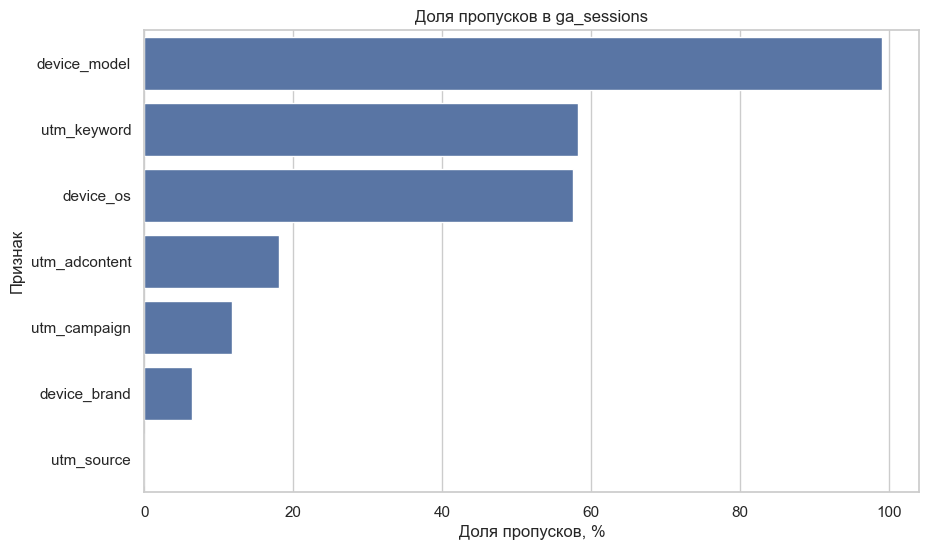

In [13]:
# График пропусков
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sessions_missing[sessions_missing["missing_percent"] > 0],
    x="missing_percent",
    y="column",
)
plt.title("Доля пропусков в ga_sessions")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Признак")
plt.show()

## Проверка пропусков в ga_hits

In [14]:
hits_missing = (
    hits.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

hits_missing.columns = ["column", "missing_percent"]
hits_missing

,column,missing_percent
0,event_value,100.00
1,hit_time,58.25
2,hit_referer,39.90
3,event_label,23.91
4,session_id,0.00
5,hit_date,0.00
6,hit_number,0.00
7,hit_type,0.00
8,hit_page_path,0.00
9,event_category,0.00


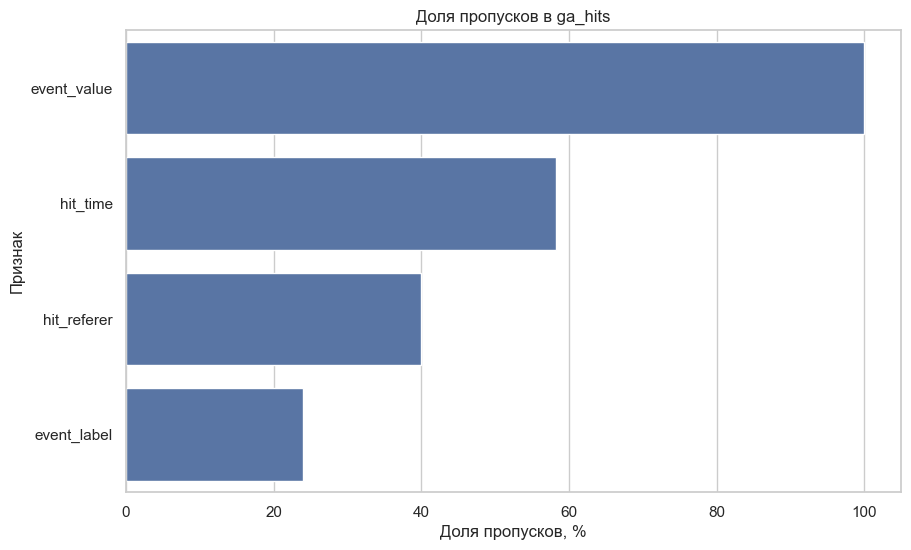

In [15]:
# График пропусков
plt.figure(figsize=(10, 6))
sns.barplot(
    data=hits_missing[hits_missing["missing_percent"] > 0],
    x="missing_percent",
    y="column",
)
plt.title("Доля пропусков в ga_hits")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Признак")
plt.show()

## Проверка дубликатов

In [16]:
# Для sessions
sessions_duplicates = sessions.duplicated().sum()
sessions_duplicates

np.int64(0)

In [17]:
# Для hits считаем по ключам, так как таблица большая
sessions["session_id"].duplicated().sum()

np.int64(0)

In [18]:
hits[["session_id", "hit_number"]].duplicated().sum()

np.int64(225862)

## Уникальные значения по основным признакам sessions

In [19]:
session_categorical_columns = [
    "utm_source",
    "utm_medium",
    "utm_campaign",
    "utm_keyword",
    "device_category",
    "device_os",
    "device_brand",
    "device_model",
    "device_browser",
    "geo_country",
    "geo_city",
]

sessions[session_categorical_columns].nunique().sort_values(ascending=False)

geo_city           2548
utm_keyword        1219
utm_campaign        412
utm_source          293
device_brand        206
geo_country         166
device_model        104
device_browser       57
utm_medium           56
device_os            13
device_category       3
dtype: int64

## Частотный анализ основных признаков

In [20]:
for column in ["utm_medium", "device_category", "device_browser", "geo_country"]:
    display(
        sessions[column]
        .value_counts(dropna=False)
        .head(20)
        .to_frame("count")
    )

,count
utm_medium,
banner,552272
cpc,434794
(none),300575
cpm,242083
referral,152050
organic,63034
email,29240
push,28035
stories,10582


,count
device_category,
mobile,1474871
desktop,366863
tablet,18308


,count
device_browser,
Chrome,1013436
Safari,478562
YaBrowser,133311
Safari (in-app),69912
Android Webview,55369
Samsung Internet,47309
Opera,26817
Firefox,16588
Edge,16065


,count
geo_country,
Russia,1800565
United States,11784
Ukraine,9012
Ireland,4034
Belarus,3636
Sweden,2694
Kazakhstan,2279
Germany,2232
Turkey,1953


## Анализ event_action

In [21]:
# Необходимо для target
event_action_counts = (
    hits["event_action"]
    .value_counts(dropna=False)
    .head(50)
    .reset_index()
)

event_action_counts.columns = ["event_action", "count"]
event_action_counts

,event_action,count
0,view_card,3558985
1,view_new_card,3551009
2,sub_landing,1798117
3,go_to_car_card,973666
4,sub_view_cars_click,791515
5,search_form_region,512069
6,search_form_search_btn,433748
7,sap_search_form_cost_to,356596
8,showed_number_ads,326274
9,pagination_click,248944


In [22]:
# Отдельно сохраняем все уникальные значения в файл
# для удобства изучения
event_actions = (
    hits["event_action"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

event_actions.to_csv("../outputs/event_actions.csv", index=False)

event_actions.head(100)

0                                   add_ad_btn
1                                 analystlabel
2                      auto_subscription_click
3                     automatic_return_to_chat
4                         back_to_change_phone
5                              back_to_options
6           backward_to_additional_information
7                       backward_to_basic_data
8                             backward_to_city
9                      backward_to_description
10                       backward_to_documents
11                         backward_to_options
12                           backward_to_photo
13                           backward_to_price
14                                   calculate
15                             callback button
16                          callback requested
17                            chat established
18                              chat requested
19                                  click_auto
20                     click_auto_subscription
21           

## Промежуточные выводы по первичному анализу данных

На этапе первичного анализа были изучены две исходные таблицы: `ga_sessions` и `ga_hits`.

1. Размеры табилц
    Таблица `ga_sessions` содержит данные о визитах пользователей на сайт.
    В ней находится 1 860 042 строки и 18 столбцов.
    Каждая строка соответствует одному визиту пользователя.
    Поле `session_id` является уникальным, поэтому его можно использовать как ключ для объединения с агрегированными данными из таблицы событий.

    Таблица `ga_hits` содержит данные о событиях пользователей на сайте.
    В ней находится 15 726 470 строк и 11 столбцов.
    Каждая строка соответствует одному событию внутри визита.
    Таблица значительно больше `ga_sessions`, поэтому дальнейшую обработку событий будем выполнять аккуратно,
    то есть с отбором нужных колонок и агрегацией по `session_id`.

2. Пропуски
    В таблице `ga_sessions` обнаружены пропуски в нескольких признаках.
    Наибольшая доля пропусков наблюдается в признаке `device_model` -> около 99.12%.
    Такой признак почти не содержит полезной информации, поэтому будет исключен из модели.
    Также значительная доля пропусков есть в `utm_keyword` -> 58.17% и `device_os` -> 57.53%.
    Эти признаки пока не удаляем, так как отсутствие значения может быть связано с источником трафика или особенностями устройства пользователя.
    Для моделей пропуски в категориальных признаках можно будет заполнить отдельным значением `unknown`.

    В таблице `ga_hits` полностью пустым является признак `event_value`, поэтому он не будет использоваться в дальнейшем анализе.
    Также много пропусков содержат `hit_time` -> 58.25%, `hit_referer` -> 39.90% и `event_label` -> 23.91%.
    При этом ключевое поле для формирования целевой переменной `event_action` не содержит пропусков,
    что позволит корректно определить целевые действия пользователей.

3. Дубликаты
    Полных дубликатов в таблице `ga_sessions` не обнаружено.
    Также поле `session_id` в этой таблице не содержит повторов, то есть одна строка соответствует одному визиту.
    В таблице `ga_hits` обнаружены повторяющиеся пары `session_id` и `hit_number`.
    Так как таблица хранит события, такие повторы могут быть связаны с несколькими действиями
    в рамках одного шага или особенностями логирования Google Analytics.
    Для формирования целевой переменной это не является критичной проблемой,
    так как целевое действие будет определяться по факту наличия хотя бы одного нужного события в сессии.

4. Анализ категориальных признаков
    Анализ категориальных признаков показал, что часть признаков имеет высокую кардинальность (очень много уникальных значений).

    Больше всего уникальных значений содержит:
    - `geo_city` -> 2548
    - `utm_keyword` -> 1219,
    - `utm_campaign` -> 412,
    - `utm_source` -> 293
    - `device_brand` -> 206

    При обучении модели такие признаки нужно будет обрабатывать аккуратно,
    чтобы не получить слишком большое количество разреженных признаков после кодирования.
    Один из возможных подходов, объединять редкие категории в значение `other`.

    Распределение по `utm_medium` показывает, что значительная часть визитов приходит из рекламных каналов: `banner`, `cpc`, `cpm`.
    Также присутствуют органические или условно бесплатные источники: `(none)`, `referral`, `organic`.
    На основе этого признака в дальнейшем можно создать дополнительный бинарный признак органического трафика.

    По типу устройства преобладают мобильные визиты.
    Значение `mobile` встречается 1 474 871 раз, `desktop` - 366 863 раза, `tablet` - 18 308 раз.
    Это говорит о том, что основная часть пользователей взаимодействует с сайтом с мобильных устройств,
    поэтому мобильный пользовательский путь может существенно влиять на конверсию.

    По браузерам лидируют `Chrome` и `Safari`.
    Также заметную долю занимают `YaBrowser`, `Safari (in-app)` и `Android Webview`.
    Наличие in-app и WebView браузеров может указывать на переходы из мобильных приложений,
    рекламных источников или социальных сетей.

    По географии большая часть визитов относится к России -> 1 800 565 визитов.
    Остальные страны представлены значительно меньшим количеством визитов.
    Поэтому признак `geo_country` может быть менее информативным, чем `geo_city`,
    но окончательное решение о его использовании лучше принимать после анализа связи с целевой переменной.

    В поле `event_action` найдено 100 уникальных действий.
    Наиболее частые действия связаны с просмотром карточек автомобилей, переходами по каталогу,
    поиском и пагинацией:
    - `view_card`
    - `view_new_card`
    - `sub_landing`
    - `go_to_car_card`
    - `sub_view_cars_click`
    - `search_form_region`
    - `search_form_search_btn`
    - `pagination_click`

    Эти действия описывают поведение пользователя на сайте.

5. Итог
    Для формирования целевой переменной необходимо отдельно определить список целевых действий.
    Для этого будет изучен полный список значений `event_action` и выбраны действия, которые отражают конверсию.

## Определение целевых действий

После изучения `event_actions.csv` прихожу к выводу, что целевая переменная формируется на уровне визита.
Визит считается конверсионным, если в рамках соответствующего `session_id` было совершено хотя бы одно целевое действие.

В качестве целевых действий выбраны события, связанные с:
- отправкой заявки
- заказом звонка
- открытием диалога
- началом общения в чате
- успешной отправкой формы

Навигационные события, просмотры карточек, клики по фильтрам, поиск и пагинация не включаются в целевую переменную,
так как они отражают интерес пользователя, но не являются конечной конверсией.

Выделим следующи список целевых событий -> `sessions_tasks.classical_ml.session02.sber_auto_subscription.src.config.TARGET_ACTIONS`

## Проверим, сколько таких событий есть в hits

In [23]:
target_action_counts = (
    hits.loc[hits["event_action"].isin(TARGET_ACTIONS), "event_action"]
    .value_counts()
    .reset_index()
)

target_action_counts.columns = ["event_action", "count"]
target_action_counts

,event_action,count
0,start_chat,66287
1,sub_open_dialog_click,25870
2,sub_submit_success,18439
3,sub_car_claim_submit_click,12359
4,sub_call_number_click,3653
5,sub_callback_submit_click,3074
6,sub_car_request_submit_click,2966
7,chat requested,2114
8,chat established,2066
9,greenday_sub_callback_submit_click,950


## Проверим, сколько уникальных сессий с целевым действием

In [24]:
target_sessions = (
    hits.loc[hits["event_action"].isin(TARGET_ACTIONS), "session_id"]
    .drop_duplicates()
)

print(f"Количество сессий с целевым действием: {target_sessions.shape[0]}")
print(f"Доля таких сессий от всех визитов: {target_sessions.shape[0] / sessions.shape[0]:.4%}")

Количество сессий с целевым действием: 63261
Доля таких сессий от всех визитов: 3.4011%


## Формируем target

In [25]:
sessions_with_target = sessions.copy()

sessions_with_target["target"] = (
    sessions_with_target["session_id"]
    .isin(target_sessions)
    .astype(int)
)

sessions_with_target["target"].value_counts(normalize=True).mul(100).round(2)

target
0    96.62
1     3.38
Name: proportion, dtype: float64

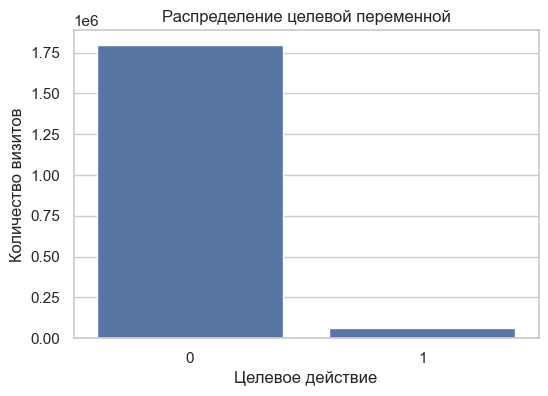

In [26]:
# Формируем график для наглядности
plt.figure(figsize=(6, 4))
sns.countplot(
    data=sessions_with_target,
    x="target",
)
plt.title("Распределение целевой переменной")
plt.xlabel("Целевое действие")
plt.ylabel("Количество визитов")
plt.show()

In [27]:
# Отдельно проверим "request", чтобы понять, связан ли он с заявкой
request_rows = hits.loc[
    hits["event_action"].eq("request"),
    ["event_category", "event_action", "event_label", "hit_page_path"]
]
# Смотри размер
request_rows.shape

(5, 4)

In [28]:
# Выводим "request"
request_rows

,event_category,event_action,event_label,hit_page_path
3022316,credit_landing_pos,request,CrrunAGcMeaKiZxLIPyx,sberauto.com/cars?utm_source_initial=sbol&utm_...
8359817,credit_landing_pos,request,CrrunAGcMeaKiZxLIPyx,sberauto.com/cars?utm_source_initial=youtube&u...
8790138,credit_landing_pos,request,CrrunAGcMeaKiZxLIPyx,sberauto.com/cars?utm_source_initial=sbol&utm_...
9041169,credit_landing_pos,request,CrrunAGcMeaKiZxLIPyx,sberauto.com/?brand=246=model=2950=generation=...
10441818,credit_landing_pos,request,CrrunAGcMeaKiZxLIPyx,sberauto.com/cars?brand=232=model=2828=model=2...


## Выводы по формированию целевой переменной

Целевая переменная была сформирована на уровне визита пользователя.

Визит считается конверсионным, если в рамках соответствующего `session_id` было совершено хотя бы одно целевое действие из заранее определенного списка.
В список целевых действий были включены события, связанные с
успешной отправкой заявки, заказом звонка, открытием диалога, началом чата и передачей контактных данных.

После формирования целевой переменной было получено 63 261 визитов с целевым действием, что составляет около 3.4% от всех визитов.

Распределение классов является несбалансированным, большая часть визитов не приводит к целевому действию.
Поэтому для оценки качества модели далее будет использоваться метрика ROC-AUC,
так как она лучше подходит для бинарной классификации с дисбалансом классов, чем простая accuracy.

Дополнительно было проверено событие `request`.
Оно встречается всего 5 раз и относится к категории `credit_landing_pos`,
поэтому не было включено в список целевых действий для основной задачи автоподписки.

## Анализ конверсии по основным признакам
```
CR по utm_medium
CR по device_category
CR по device_browser
CR по geo_country
CR по geo_city
CR по visit_number
```

Для этого удобно сделать функцию `calculate_cr_by_column`.

In [29]:
# Функция расчета CR
def calculate_cr_by_column(
    data: pd.DataFrame,
    column: str,
    target_column: str = "target",
    min_count: int = 1000,
) -> pd.DataFrame:
    """
    Рассчитывает количество визитов и конверсию по выбранному признаку.

    Аргументы:
        - data: DataFrame с данными на уровне визитов
        - column: Название признака для группировки
        - target_column: Название целевой переменной
        - min_count: Минимальное количество визитов в группе
            (группы с меньшим количеством визитов исключаются из результата,
            чтобы не делать выводы по слишком малым выборкам)

    Возвращает:
        DataFrame со статистикой по группам:
            - visits: количество визитов
            - target_visits: количество визитов с целевым действием
            - cr: конверсия в долях
            - cr_percent: конверсия в процентах
    """

    cr_table = (
        data
        .groupby(column, dropna=False)
        .agg(
            visits=(target_column, "count"),
            target_visits=(target_column, "sum"),
            cr=(target_column, "mean"),
        )
        .reset_index()
    )

    cr_table["cr_percent"] = (cr_table["cr"] * 100).round(2)

    cr_table = cr_table[cr_table["visits"] >= min_count]

    cr_table = (
        cr_table
        .sort_values("cr", ascending=False)
        .reset_index(drop=True)
    )

    return cr_table

## CR по utm_medium

In [30]:
utm_medium_cr = calculate_cr_by_column(
    data=sessions_with_target,
    column="utm_medium",
    min_count=1000,
)

utm_medium_cr.head(20)

,utm_medium,visits,target_visits,cr,cr_percent
0,smm,1985,277,0.139547,13.95
1,referral,152050,9496,0.062453,6.25
2,banner,552272,22907,0.041478,4.15
3,organic,63034,2544,0.040359,4.04
4,(none),300575,10532,0.035040,3.50
5,push,28035,959,0.034207,3.42
6,smartbanner,6794,222,0.032676,3.27
7,blogger_channel,8015,229,0.028571,2.86
8,cpa,4279,118,0.027577,2.76
9,email,29240,777,0.026573,2.66


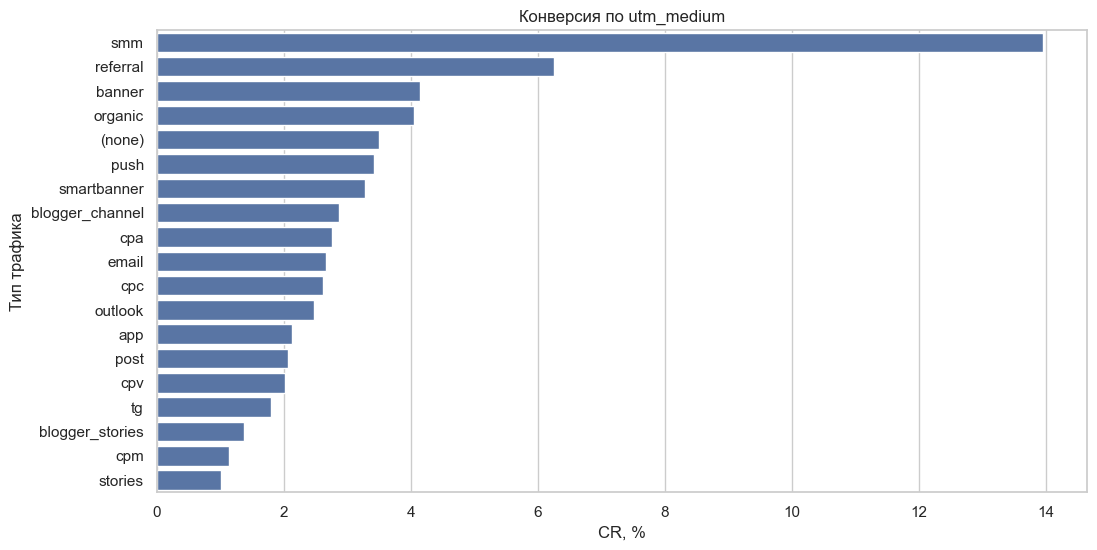

In [31]:
# График
plt.figure(figsize=(12, 6))
sns.barplot(
    data=utm_medium_cr.head(20),
    x="cr_percent",
    y="utm_medium",
)
plt.title("Конверсия по utm_medium")
plt.xlabel("CR, %")
plt.ylabel("Тип трафика")
plt.show()

## CR по устройствам

In [32]:
device_category_cr = calculate_cr_by_column(
    data=sessions_with_target,
    column="device_category",
    min_count=1000,
)

device_category_cr

,device_category,visits,target_visits,cr,cr_percent
0,desktop,366863,14025,0.038230,3.82
1,mobile,1474871,48349,0.032782,3.28
2,tablet,18308,528,0.028840,2.88


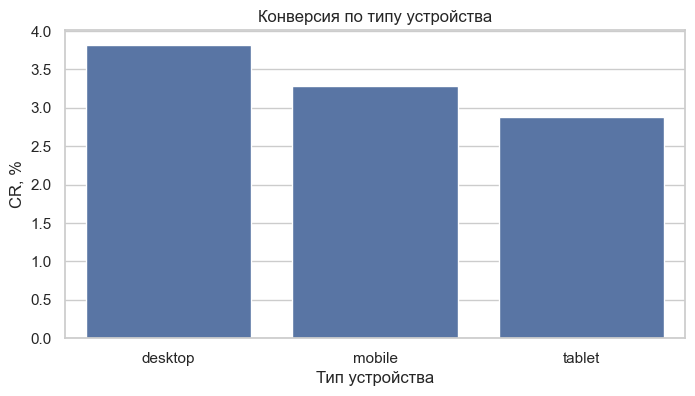

In [33]:
# График
plt.figure(figsize=(8, 4))
sns.barplot(
    data=device_category_cr,
    x="device_category",
    y="cr_percent",
)
plt.title("Конверсия по типу устройства")
plt.xlabel("Тип устройства")
plt.ylabel("CR, %")
plt.show()

## CR по браузерам

In [34]:
device_browser_cr = calculate_cr_by_column(
    data=sessions_with_target,
    column="device_browser",
    min_count=1000,
)

device_browser_cr.head(20)

,device_browser,visits,target_visits,cr,cr_percent
0,Firefox,16588,686,0.041355,4.14
1,Edge,16065,652,0.040585,4.06
2,YaBrowser,133311,4996,0.037476,3.75
3,Chrome,1013436,36451,0.035968,3.60
4,Safari,478562,14976,0.031294,3.13
5,Samsung Internet,47309,1433,0.030290,3.03
6,Android Webview,55369,1658,0.029945,2.99
7,Opera,26817,697,0.025991,2.60
8,Safari (in-app),69912,1331,0.019038,1.90


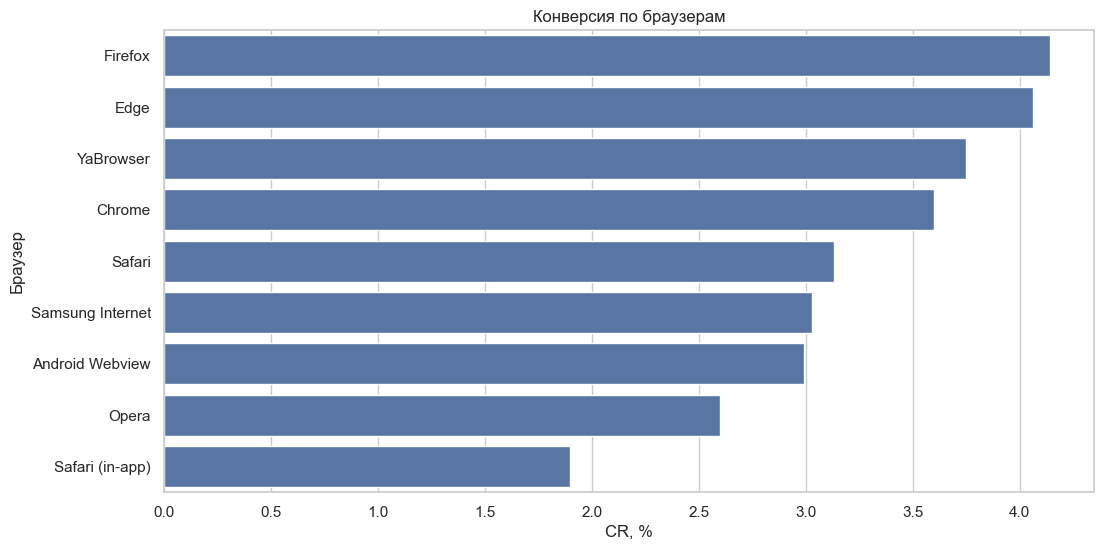

In [35]:
# График
plt.figure(figsize=(12, 6))
sns.barplot(
    data=device_browser_cr.head(20),
    x="cr_percent",
    y="device_browser",
)
plt.title("Конверсия по браузерам")
plt.xlabel("CR, %")
plt.ylabel("Браузер")
plt.show()

## CR по странам

In [36]:
geo_country_cr = calculate_cr_by_column(
    data=sessions_with_target,
    column="geo_country",
    min_count=1000,
)

geo_country_cr.head(20)

,geo_country,visits,target_visits,cr,cr_percent
0,Germany,2232,93,0.041667,4.17
1,Turkey,1953,72,0.036866,3.69
2,Russia,1800565,61548,0.034183,3.42
3,Ukraine,9012,301,0.033400,3.34
4,Netherlands,1549,50,0.032279,3.23
5,United Kingdom,1462,45,0.030780,3.08
6,Kazakhstan,2279,63,0.027644,2.76
7,Uzbekistan,1523,38,0.024951,2.50
8,(not set),1146,27,0.023560,2.36
9,Belarus,3636,79,0.021727,2.17


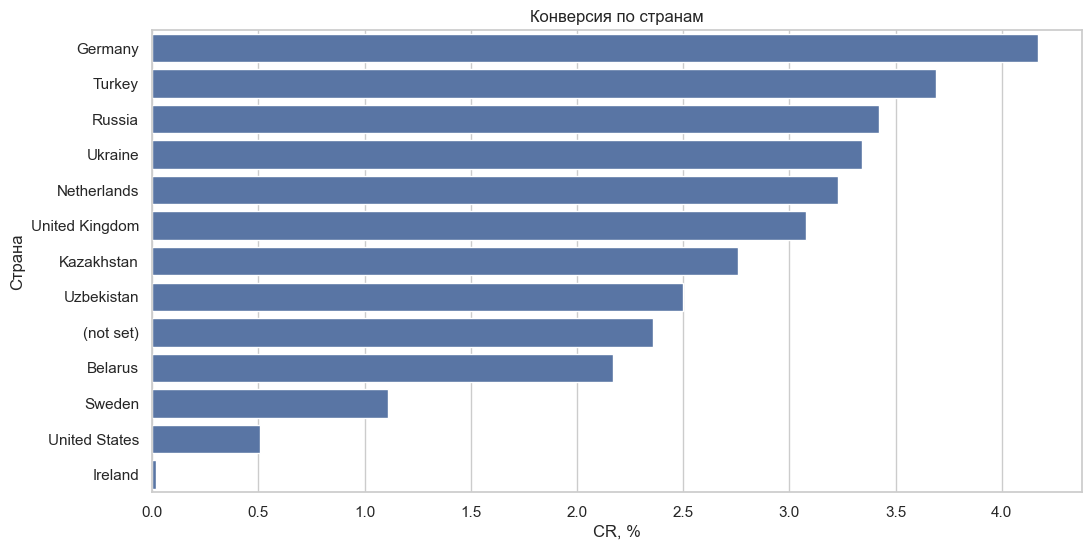

In [37]:
# График
plt.figure(figsize=(12, 6))
sns.barplot(
    data=geo_country_cr.head(20),
    x="cr_percent",
    y="geo_country",
)
plt.title("Конверсия по странам")
plt.xlabel("CR, %")
plt.ylabel("Страна")
plt.show()

## CR по городам

In [38]:
geo_city_cr = calculate_cr_by_column(
    data=sessions_with_target,
    column="geo_city",
    min_count=3000,
)

geo_city_cr.head(20)

,geo_city,visits,target_visits,cr,cr_percent
0,Domodedovo,4038,247,0.061169,6.12
1,Stavropol,4377,235,0.053690,5.37
2,Kazan,29531,1388,0.047001,4.70
3,Lipetsk,4531,206,0.045465,4.55
4,Irkutsk,13532,607,0.044857,4.49
5,Sochi,8972,401,0.044695,4.47
6,Korolyov,4047,178,0.043983,4.40
7,Krasnodar,32243,1416,0.043917,4.39
8,Rostov-on-Don,13886,607,0.043713,4.37
9,Grozny,12742,554,0.043478,4.35


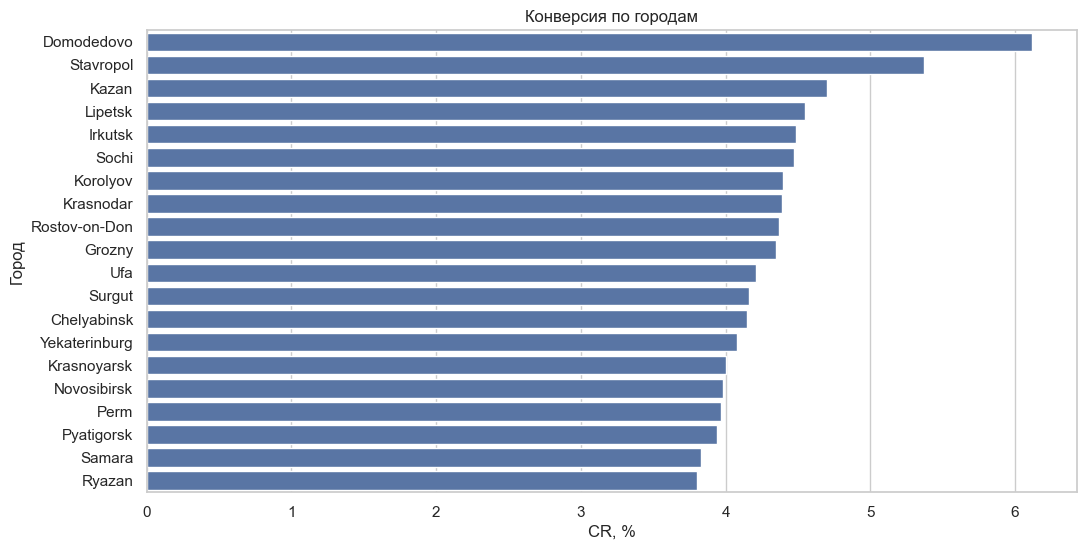

In [39]:
# График
plt.figure(figsize=(12, 6))
sns.barplot(
    data=geo_city_cr.head(20),
    x="cr_percent",
    y="geo_city",
)
plt.title("Конверсия по городам")
plt.xlabel("CR, %")
plt.ylabel("Город")
plt.show()

## Органический и платный трафик

In [40]:
ORGANIC_MEDIUMS = ["organic", "referral", "(none)"]

sessions_with_target["traffic_type"] = np.where(
    sessions_with_target["utm_medium"].isin(ORGANIC_MEDIUMS),
    "organic",
    "paid",
)

traffic_type_cr = calculate_cr_by_column(
    data=sessions_with_target,
    column="traffic_type",
    min_count=1000,
)

traffic_type_cr

,traffic_type,visits,target_visits,cr,cr_percent
0,organic,515659,22572,0.043773,4.38
1,paid,1344383,40330,0.029999,3.00


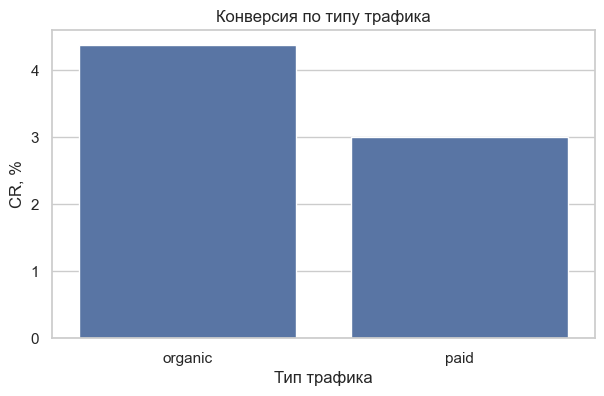

In [41]:
# График
plt.figure(figsize=(7, 4))
sns.barplot(
    data=traffic_type_cr,
    x="traffic_type",
    y="cr_percent",
)
plt.title("Конверсия по типу трафика")
plt.xlabel("Тип трафика")
plt.ylabel("CR, %")
plt.show()

## Выводы по анализу конверсии

После формирования целевой переменной была проанализирована конверсия по основным признакам визита, типу трафика, устройству, браузеру и географии.

Общая доля визитов с целевым действием составляет около 3.4%.
Это означает, что данные имеют выраженный дисбаланс классов, большая часть пользователей не совершает целевое действие.
Поэтому при построении модели важно использовать метрику ROC-AUC, а не accuracy.

### Конверсия по типу трафика

Анализ `utm_medium` показал, что разные каналы привлечения заметно отличаются по конверсии.

Наиболее высокая конверсия среди каналов с достаточным количеством визитов наблюдается у `smm` -> около 13.95% (1 985 визитов).

Также высокую конверсию показывают:

- `referral` -> около 6.25%
- `banner` -> около 4.15%
- `organic` -> около 4.04%
- `(none)` -> около 3.50%
- `push` -> около 3.42%

Это говорит о том, что источник и тип трафика могут быть важными признаками для модели.

Дополнительное разделение трафика на органический и платный показало, что органический трафик конвертируется лучше:

- `organic` traffic -> около 4.38%
- `paid` traffic -> около 3.00%

Таким образом, органический и реферальный трафик выглядит более качественным с точки зрения вероятности совершения целевого действия.

### Конверсия по устройствам

По типу устройства наблюдаются следующие результаты:

- `desktop` -> около 3.82%
- `mobile` -> около 3.28%
- `tablet` -> около 2.88%

Несмотря на то что большая часть визитов приходится на мобильные устройства, пользователи с desktop чаще совершают целевое действие.
Это может говорить о том, что оформление заявки или взаимодействие с сайтом удобнее на большом экране,
либо desktop-пользователи находятся на более позднем этапе принятия решения.

### Конверсия по браузерам

По браузерам наибольшую конверсию показывают:

- `Firefox` -> около 4.14%
- `Edge` -> около 4.06%
- `YaBrowser` -> около 3.75%
- `Chrome` -> около 3.60%
- `Safari` -> около 3.13%

Низкая конверсия обнаружена у `Safari (in-app)` -> около 1.90%.
Это может быть связано с особенностями in-app браузеров, переходами из мобильных приложений или
менее удобным пользовательским сценарием внутри встроенного браузера.

### Конверсия по странам

Большая часть визитов относится к России -> около 3.42%.

Некоторые страны показывают более высокую конверсию, например Германия и Турция,
однако количество визитов по ним значительно меньше, чем по России.

### Конверсия по городам

Анализ городов показал заметные различия в конверсии.
Среди городов с количеством визитов не менее 3000 наибольшую конверсию показывают:

- `Domodedovo` -> около 6.12%
- `Stavropol` -> около 5.37%
- `Kazan` -> около 4.70%
- `Lipetsk` -> около 4.55%
- `Irkutsk` -> около 4.49%
- `Sochi` -> около 4.47%

Это говорит о том, что география пользователя может быть связана с вероятностью совершения целевого действия.
При этом признак `geo_city` имеет высокую кардинальность,
поэтому при обучении модели его нужно обработать дополнительно, объединять редкие города в категорию `other`.

### Общий вывод

EDA показал, что на вероятность целевого действия могут влиять:

- источник и тип трафика
- органический или платный характер визита
- тип устройства
- браузер
- география пользователя

In [42]:
# Сохраняем промежуточный датасет уровня сессии
eda_dataset_path = PROCESSED_DATA_DIR / "sessions_with_target.csv"

sessions_with_target.to_csv(eda_dataset_path, index=False)

print(f"Датасет с целевой переменной сохранен: {eda_dataset_path}")
print(f"Размер датасета: {sessions_with_target.shape}")

Датасет с целевой переменной сохранен: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/data/processed/sessions_with_target.csv
Размер датасета: (1860042, 20)


## Итог первого этапа

На первом этапе были загружены и изучены исходные данные,
проверены пропуски и дубликаты, проанализированы основные категориальные признаки,
сформирована целевая переменная и рассчитана конверсия по ключевым группам пользователей.

В результате был подготовлен датасет уровня визита с целевой переменной `target`.
Этот датасет будет использован на следующем этапе для создания дополнительных признаков и подготовки обучающей выборки.